#**Causaual AI Quyết định duyệt vay có điều kiện**
* **Dataset:** https://www.kaggle.com/datasets/ethon0426/lending-club-20072020q1
* **Base paper:** https://www.sciencedirect.com/science/article/pii/S2667305325000407

##**1. Cài đặt các thư viện**

In [1]:
!pip install causal-learn networkx matplotlib torch

#NOTEARS: Tìm đồ thị nhân quả
!pip install git+https://github.com/xunzheng/notears.git

#DOWHY: Causal inference
!pip install dowhy

!pip install catboost


  Cloning https://github.com/xunzheng/notears.git to /tmp/pip-req-build-ribwqe2a
  Running command git clone --filter=blob:none --quiet https://github.com/xunzheng/notears.git /tmp/pip-req-build-ribwqe2a
  Resolved https://github.com/xunzheng/notears.git to commit 4a9ab19fe502e392503da331773c5223d82d3666
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# ==============================================================================
# 2. ĐỌC DỮ LIỆU & LỌC PHÂN KHÚC VAY ĐẢO NỢ (DEBT CONSOLIDATION COHORT)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import category_encoders as ce

file_path = 'data/Loan_status_2007-2020Q3.gzip'
df = pd.read_csv(file_path, low_memory=False)
print(f"Kích thước dữ liệu gốc ban đầu: {df.shape}")

# 2.1. Loại bỏ triệt để rò rỉ dữ liệu hậu giải ngân & văn bản
cols_to_remove = [
    'id', 'member_id', 'url', 'title', 'desc', 'emp_title', 'zip_code', 'policy_code',
    "last_pymnt_amnt", "last_pymnt_d", "next_pymnt_d", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee", "out_prncp", "out_prncp_inv",
    "last_credit_pull_d", "last_fico_range_high", "last_fico_range_low", "pymnt_plan",
    "funded_amnt", "funded_amnt_inv", "recoveries", "collection_recovery_fee",
    "hardship_flag", "hardship_type", "hardship_reason", "hardship_status",
    "hardship_loan_status", "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount", "hardship_start_date",
    "hardship_end_date", "payment_plan_start_date", "hardship_length", "hardship_dpd",
    "hardship_amount", "deferral_term", "debt_settlement_flag", "debt_settlement_flag_date",
    "settlement_status", "settlement_date", "settlement_amount", "settlement_percentage", "settlement_term"
]
df = df.drop(columns=[c for c in cols_to_remove if c in df.columns])

# 2.2. Lọc bỏ các cột khuyết thiếu > 80%
missing_ratios = df.isnull().mean()
df = df.drop(columns=missing_ratios[missing_ratios > 0.80].index)

# 2.3. ĐIỂM KHÁC BIỆT 1: LỌC CHUYÊN BIỆT PHÂN KHÚC VAY ĐẢO NỢ (DEBT CONSOLIDATION)
df = df[df['purpose'] == 'debt_consolidation'].copy()
df = df.drop(columns=['purpose']) # Bỏ cột này vì 100% mẫu đều là debt_consolidation
print(f"Số lượng khoản vay đảo nợ thu thập được: {len(df)}")

# 2.4. Lọc trạng thái hoàn tất và cân bằng mẫu (10k tốt / 10k xấu)
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

df_good = df[df['loan_status'] == 0]
df_bad = df[df['loan_status'] == 1]
df_balanced = pd.concat([
    resample(df_good, replace=False, n_samples=10000, random_state=42),
    resample(df_bad, replace=False, n_samples=10000, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# 2.5. Làm sạch định dạng số
for col in ['int_rate', 'revol_util', 'il_util', 'bc_util', 'all_util']:
    if col in df_balanced.columns:
        df_balanced[col] = (df_balanced[col].astype(str).str.replace('%', '', regex=False).str.strip())
        df_balanced[col] = pd.to_numeric(df_balanced[col], errors='coerce') / 100.0

if 'term' in df_balanced.columns:
    df_balanced['term'] = df_balanced['term'].astype(str).str.extract('(\\d+)').astype(float)

if 'emp_length' in df_balanced.columns:
    emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
               '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
    df_balanced['emp_length'] = df_balanced['emp_length'].map(emp_map).fillna(0).astype(float)

# 2.6. Tạo biến FICO và Thâm niên tín dụng
if 'fico_range_low' in df_balanced.columns and 'fico_range_high' in df_balanced.columns:
    df_balanced['fico_score'] = (df_balanced['fico_range_low'] + df_balanced['fico_range_high']) / 2.0
    df_balanced = df_balanced.drop(columns=['fico_range_low', 'fico_range_high'])

if 'earliest_cr_line' in df_balanced.columns and 'issue_d' in df_balanced.columns:
    cr_dt = pd.to_datetime(df_balanced['earliest_cr_line'], format='%b-%Y', errors='coerce')
    iss_dt = pd.to_datetime(df_balanced['issue_d'], format='%b-%Y', errors='coerce')
    df_balanced['credit_hist_months'] = ((iss_dt.dt.year - cr_dt.dt.year)*12 + (iss_dt.dt.month - cr_dt.dt.month)).astype(float)
    df_balanced = df_balanced.drop(columns=['earliest_cr_line', 'issue_d'])

# 2.7. Chọn lọc bộ đặc trưng thẩm định nợ
underwriting_cols = [
    'loan_amnt', 'term', 'installment', 'int_rate', 'sub_grade',
    'annual_inc', 'dti', 'emp_length', 'home_ownership',
    'fico_score', 'credit_hist_months', 'revol_bal', 'revol_util',
    'open_acc', 'total_acc', 'mort_acc', 'tot_cur_bal',
    'acc_open_past_24mths', 'loan_status'
]
df_underwriting = df_balanced[[c for c in underwriting_cols if c in df_balanced.columns]].copy()

# 2.8. Phân chia Train/Test & Điền dữ liệu khuyết thiếu
df_fit, df_eval = train_test_split(df_underwriting, test_size=4000, random_state=42, stratify=df_underwriting['loan_status'])
df_fit = df_fit.copy()
df_eval = df_eval.copy()

num_cols = df_fit.select_dtypes(include=[np.number]).columns.drop('loan_status')
cat_cols = df_fit.select_dtypes(exclude=[np.number]).columns

for col in cat_cols:
    val = df_fit[col].mode()[0] if not df_fit[col].empty else 'Unknown'
    df_fit[col] = df_fit[col].fillna(val)
    df_eval[col] = df_eval[col].fillna(val)

for col in num_cols:
    val = df_fit[col].median()
    df_fit[col] = df_fit[col].fillna(val)
    df_eval[col] = df_eval[col].fillna(val)

df_fit_gcm = df_fit.copy()
df_eval_gcm = df_eval.copy()

# Target Encoding & MinMax Scaling
encoder = ce.TargetEncoder(cols=cat_cols)
df_fit[cat_cols] = encoder.fit_transform(df_fit[cat_cols], df_fit['loan_status'])
df_eval[cat_cols] = encoder.transform(df_eval[cat_cols])

scaler = MinMaxScaler()
feats = df_fit.columns.drop('loan_status')
df_fit[feats] = scaler.fit_transform(df_fit[feats])
df_eval[feats] = scaler.transform(df_eval[feats])

scaler_gcm = MinMaxScaler()
df_fit_gcm[num_cols] = scaler_gcm.fit_transform(df_fit_gcm[num_cols])
df_eval_gcm[num_cols] = scaler_gcm.transform(df_eval_gcm[num_cols])

print(f"Chuẩn bị dữ liệu hoàn tất! Tập Train: {df_fit.shape}, Tập Test: {df_eval.shape}")

Kích thước dữ liệu gốc ban đầu: (2925493, 142)
Số lượng khoản vay đảo nợ thu thập được: 1638058
Chuẩn bị dữ liệu hoàn tất! Tập Train: (16000, 19), Tập Test: (4000, 19)


In [3]:
# ==============================================================================
# 3. HỌC CẤU TRÚC NHÂN QUẢ PHI TUYẾN CHO PHÂN KHÚC VAY ĐẢO NỢ
# ==============================================================================
import networkx as nx
from notears.nonlinear import notears_nonlinear, NotearsMLP

target = 'loan_status'
all_vars = [col for col in df_fit.columns if col != target] + [target]
target_idx = all_vars.index(target)
X_np = df_fit[all_vars].values.astype(np.float32)

print(f"Đang chạy Non-linear Causal Discovery trên phân khúc Vay Đảo Nợ ({X_np.shape[1]} biến)...")
model = NotearsMLP(dims=[X_np.shape[1], 32, 1], bias=True)
W_est = notears_nonlinear(model, X_np, lambda1=0.0001, lambda2=0.0001, max_iter=300)

threshold = 0.08
G_raw = nx.DiGraph()
G_raw.add_nodes_from(all_vars)

num_vars = len(all_vars)
for i in range(num_vars):
    for j in range(num_vars):
        if i != j and abs(W_est[i, j]) > threshold:
            if all_vars[i] == target:
                continue # Ràng buộc: Target không thể là nguyên nhân của quá khứ
            G_raw.add_edge(all_vars[i], all_vars[j], weight=W_est[i, j])

causal_ancestors = list(nx.ancestors(G_raw, target))
print(f"\n[KẾT QUẢ] Tìm thấy {len(causal_ancestors)} biến có đường truyền nhân quả đến {target}:")
print(causal_ancestors)

nodes_to_keep = causal_ancestors + [target]
causal_graph = G_raw.subgraph(nodes_to_keep).copy()

# Bẻ chu trình để đảm bảo DAG
cycles = list(nx.simple_cycles(causal_graph))
if len(cycles) > 0:
    for cycle in cycles:
        min_w = float('inf')
        edge_rem = None
        for i in range(len(cycle)):
            u, v = cycle[i], cycle[(i + 1) % len(cycle)]
            if causal_graph.has_edge(u, v):
                w = abs(W_est[all_vars.index(u), all_vars.index(v)])
                if w < min_w: min_w = w; edge_rem = (u, v)
        if edge_rem: causal_graph.remove_edge(*edge_rem)

print(f"Đồ thị đạt chuẩn DAG phi chu trình: {nx.is_directed_acyclic_graph(causal_graph)}")

Đang chạy Non-linear Causal Discovery trên phân khúc Vay Đảo Nợ (19 biến)...

[KẾT QUẢ] Tìm thấy 7 biến có đường truyền nhân quả đến loan_status:
['revol_bal', 'int_rate', 'sub_grade', 'annual_inc', 'installment', 'acc_open_past_24mths', 'tot_cur_bal']
Đồ thị đạt chuẩn DAG phi chu trình: True


-> Đã xuất đồ thị 8 nút thành công: 'causal_dag_debt_consolidation.pdf'


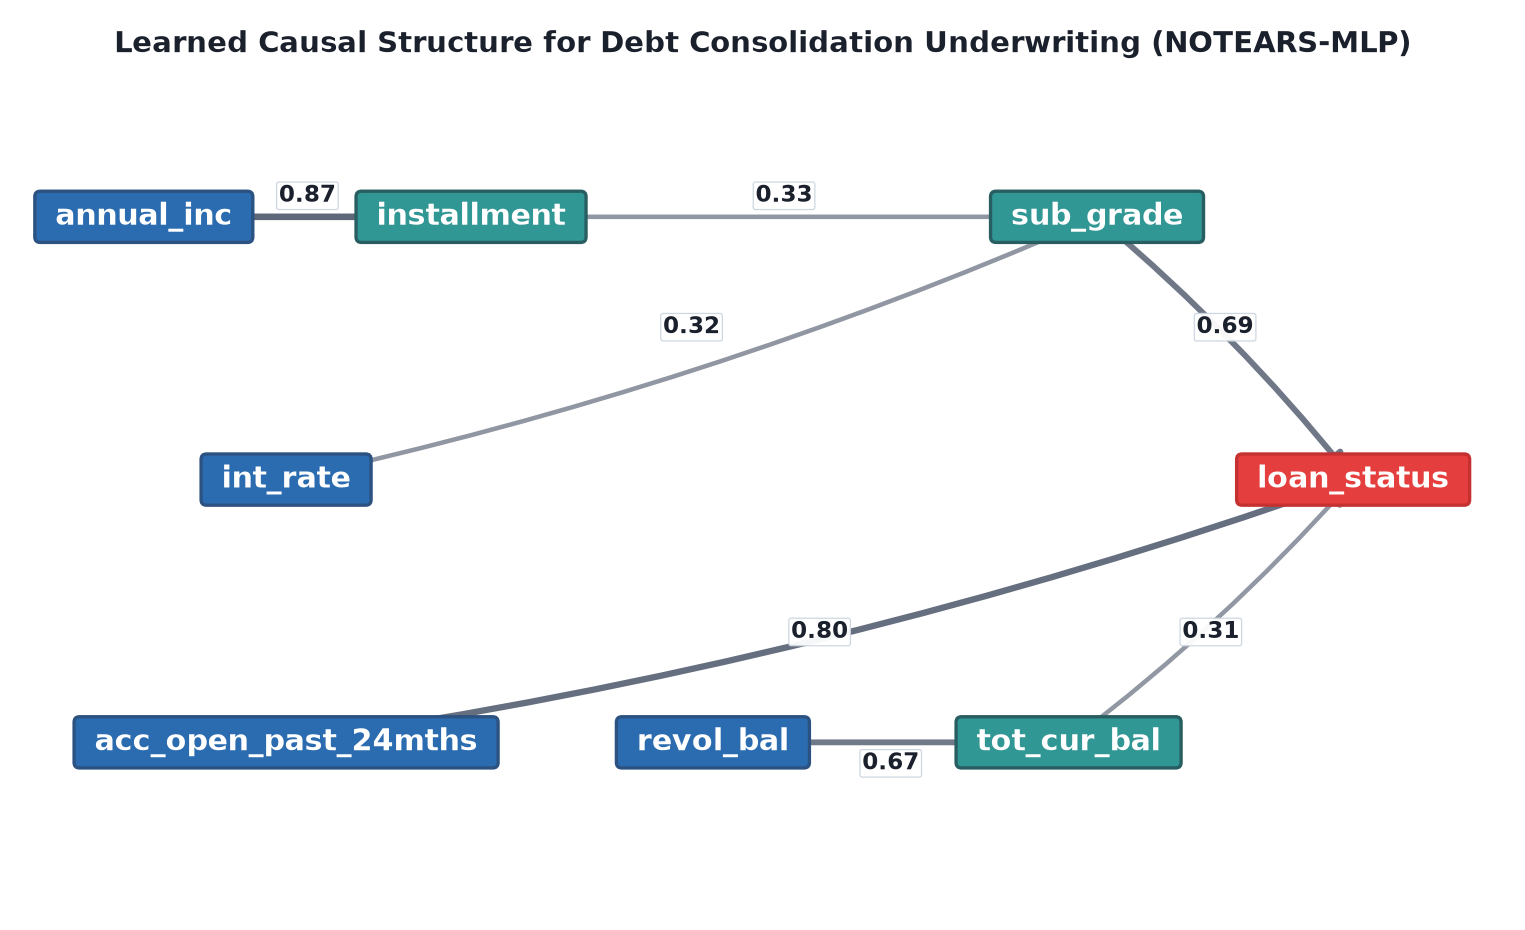

In [19]:
# ==============================================================================
# 3.4. TRỰC QUAN HÓA ĐỒ THỊ NHÂN QUẢ VAY ĐẢO NỢ (NOTEARS-MLP 8 NÚT)
# ==============================================================================
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Kích thước chuẩn tràn 2 cột bài báo (7.2 x 3.2 inch)
plt.figure(figsize=(5.2, 3.2), dpi=300)
ax = plt.gca()

# ------------------------------------------------------------------------------
# 1. TỌA ĐỘ BỐ CỤC 2 LÀN SONG SONG HOÀN HẢO CHO 8 NÚT
# ------------------------------------------------------------------------------
# pos_dag = {
#     # LÀN TRÊN: Năng lực thu nhập & Định giá gói vay (Y = 1.0)
#     'annual_inc':           (0.0,   1.0),
#     'installment':          (2.3,   1.0),
#     'int_rate':             (4.6,   1.0),
#     'sub_grade':            (6.7,   1.0),

#     # LÀN DƯỚI: Thói quen mở thẻ & Tổng dư nợ hiện hành (Y = -1.0)
#     'acc_open_past_24mths': (0.0,  -1.0),
#     'revol_bal':            (2.7,  -1.0),
#     'tot_cur_bal':          (5.6,  -1.0),

#     # ĐÍCH ĐẾN HỘI TỤ: Quyết định xét duyệt (X = 8.5, Y = 0.0)
#     'loan_status':          (8.5,   0.0)
# }


pos_dag = {
    # LÀN TRÊN: Năng lực thu nhập & Định giá gói vay (Y = 1.0)
    'annual_inc':           (0.0,   1.0),
    'installment':          (2.3,   1.0),
    'int_rate':             (1.0,   0.0),
    'sub_grade':            (6.7,   1.0),

    # LÀN DƯỚI: Thói quen mở thẻ & Tổng dư nợ hiện hành (Y = -1.0)
    'acc_open_past_24mths': (1.0,  -1.0),
    'revol_bal':            (4.0,  -1.0),
    'tot_cur_bal':          (6.5,  -1.0),

    # ĐÍCH ĐẾN HỘI TỤ: Quyết định xét duyệt (X = 8.5, Y = 0.0)
    'loan_status':          (8.5,   0.0)
}



# Dự phòng nếu có thêm biến
for idx, node in enumerate(causal_graph.nodes()):
    if node not in pos_dag:
        pos_dag[node] = (3.5, 0.0)

# ------------------------------------------------------------------------------
# 2. VẼ CÁC CẠNH MŨI TÊN NHÂN QUẢ THANH LỊCH
# ------------------------------------------------------------------------------
edge_weights = nx.get_edge_attributes(causal_graph, 'weight')

for (u, v) in causal_graph.edges():
    w = abs(edge_weights.get((u, v), 0.5))
    y_u, y_v = pos_dag[u][1], pos_dag[v][1]
    dx = pos_dag[v][0] - pos_dag[u][0]
    
    # Độ cong thông minh
    if abs(y_u - y_v) < 0.1:
        rad = 0.0  # Đi thẳng nếu cùng làn
    elif y_u * y_v < 0:
        rad = 0.06 # Chuyển làn nhẹ nhàng
    else:
        rad = -0.05 if y_u > 0 else 0.05

    line_width = 0.8 + w * 0.9
    alpha_val = min(0.92, 0.45 + w * 0.5)

    ax.annotate(
        "", xy=pos_dag[v], xytext=pos_dag[u],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#4A5568",
            lw=line_width,
            connectionstyle=f"arc3,rad={rad}",
            mutation_scale=9,
            alpha=alpha_val
        )
    )

# ------------------------------------------------------------------------------
# 3. GHI NHÃN TRỌNG SỐ GỌN GÀNG (LỌC TRỌNG SỐ >= 0.30)
# ------------------------------------------------------------------------------
for (u, v), w in edge_weights.items():
    if abs(w) >= 0.30:
        x_mid = (pos_dag[u][0] + pos_dag[v][0]) / 2.0
        y_mid = (pos_dag[u][1] + pos_dag[v][1]) / 2.0
        offset_y = 0.08 if (pos_dag[u][1] + pos_dag[v][1]) >= 0 else -0.08
        
        ax.text(
            x_mid, y_mid + offset_y, f"{w:.2f}",
            fontsize=5.5, fontweight='bold', color='#1A202C',
            ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.1", facecolor="white", edgecolor="#CBD5E0", lw=0.3, alpha=0.95)
        )

# ------------------------------------------------------------------------------
# 4. VẼ NÚT DẠNG HỘP PHẲNG (BOX BADGES)
# ------------------------------------------------------------------------------
for node in causal_graph.nodes():
    x, y = pos_dag[node]
    
    if node == target:
        fc, ec = "#E53E3E", "#C53030" # Đỏ Ruby cho Target
    elif causal_graph.in_degree(node) == 0:
        fc, ec = "#2B6CB0", "#2C5282" # Xanh Navy cho Nút Gốc (Root Causes)
    else:
        fc, ec = "#319795", "#285E61" # Xanh Ngọc cho Nút Trung gian (Mechanisms)

    ax.text(
        x, y, f" {node} ",
        fontsize=7.2, fontweight='bold', color='white',
        ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.35,rounding_size=0.18", facecolor=fc, edgecolor=ec, lw=0.8)
    )

# ------------------------------------------------------------------------------
# 5. KHUNG HÌNH & XUẤT FILE NÉT CAO CHO BÀI BÁO
# ------------------------------------------------------------------------------
plt.title("Learned Causal Structure for Debt Consolidation Underwriting (NOTEARS-MLP)", 
          fontsize=7.0, fontweight='bold', pad=1, color='#1A202C')

plt.xlim(-0.8, 9.5)
plt.ylim(-1.6, 1.6)
plt.axis('off')
plt.tight_layout()

# plt.savefig("causal_dag_debt_consolidation.pdf", bbox_inches='tight')
# plt.savefig("causal_dag_debt_consolidation.png", dpi=300, bbox_inches='tight')
print("-> Đã xuất đồ thị 8 nút thành công: 'causal_dag_debt_consolidation.pdf'")
plt.show()

/home/ngoto/miniconda3/envs/causal_approval/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ngoto/miniconda3/envs/causal_approval/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/ngoto/miniconda3/envs/causal_approval/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/ngoto/miniconda3/envs/causal_approval/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning

Đang huấn luyện Structural Causal Model...


Test permutations of given graph: 100%|██████████| 50/50 [00:17<00:00,  2.87it/s]


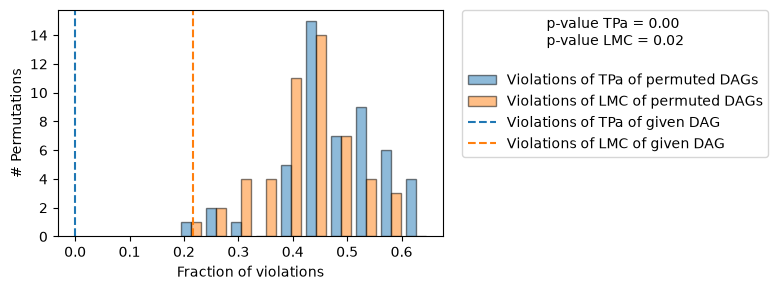

Evaluated and the overall average KL divergence between generated and observed distribution and the graph structure. The results are as follows:

==== Evaluation of Generated Distribution ====
The overall average KL divergence between the generated and observed distribution is 1.6299824219563688
The estimated KL divergence indicates some significant mismatches between the distributions.

==== Evaluation of the Causal Graph Structure ====
+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 0 / 50 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.00).                                                   |
| The given DAG violates 8/3

Evaluating set functions...: 100%|██████████| 116/116 [00:02<00:00, 57.63it/s]


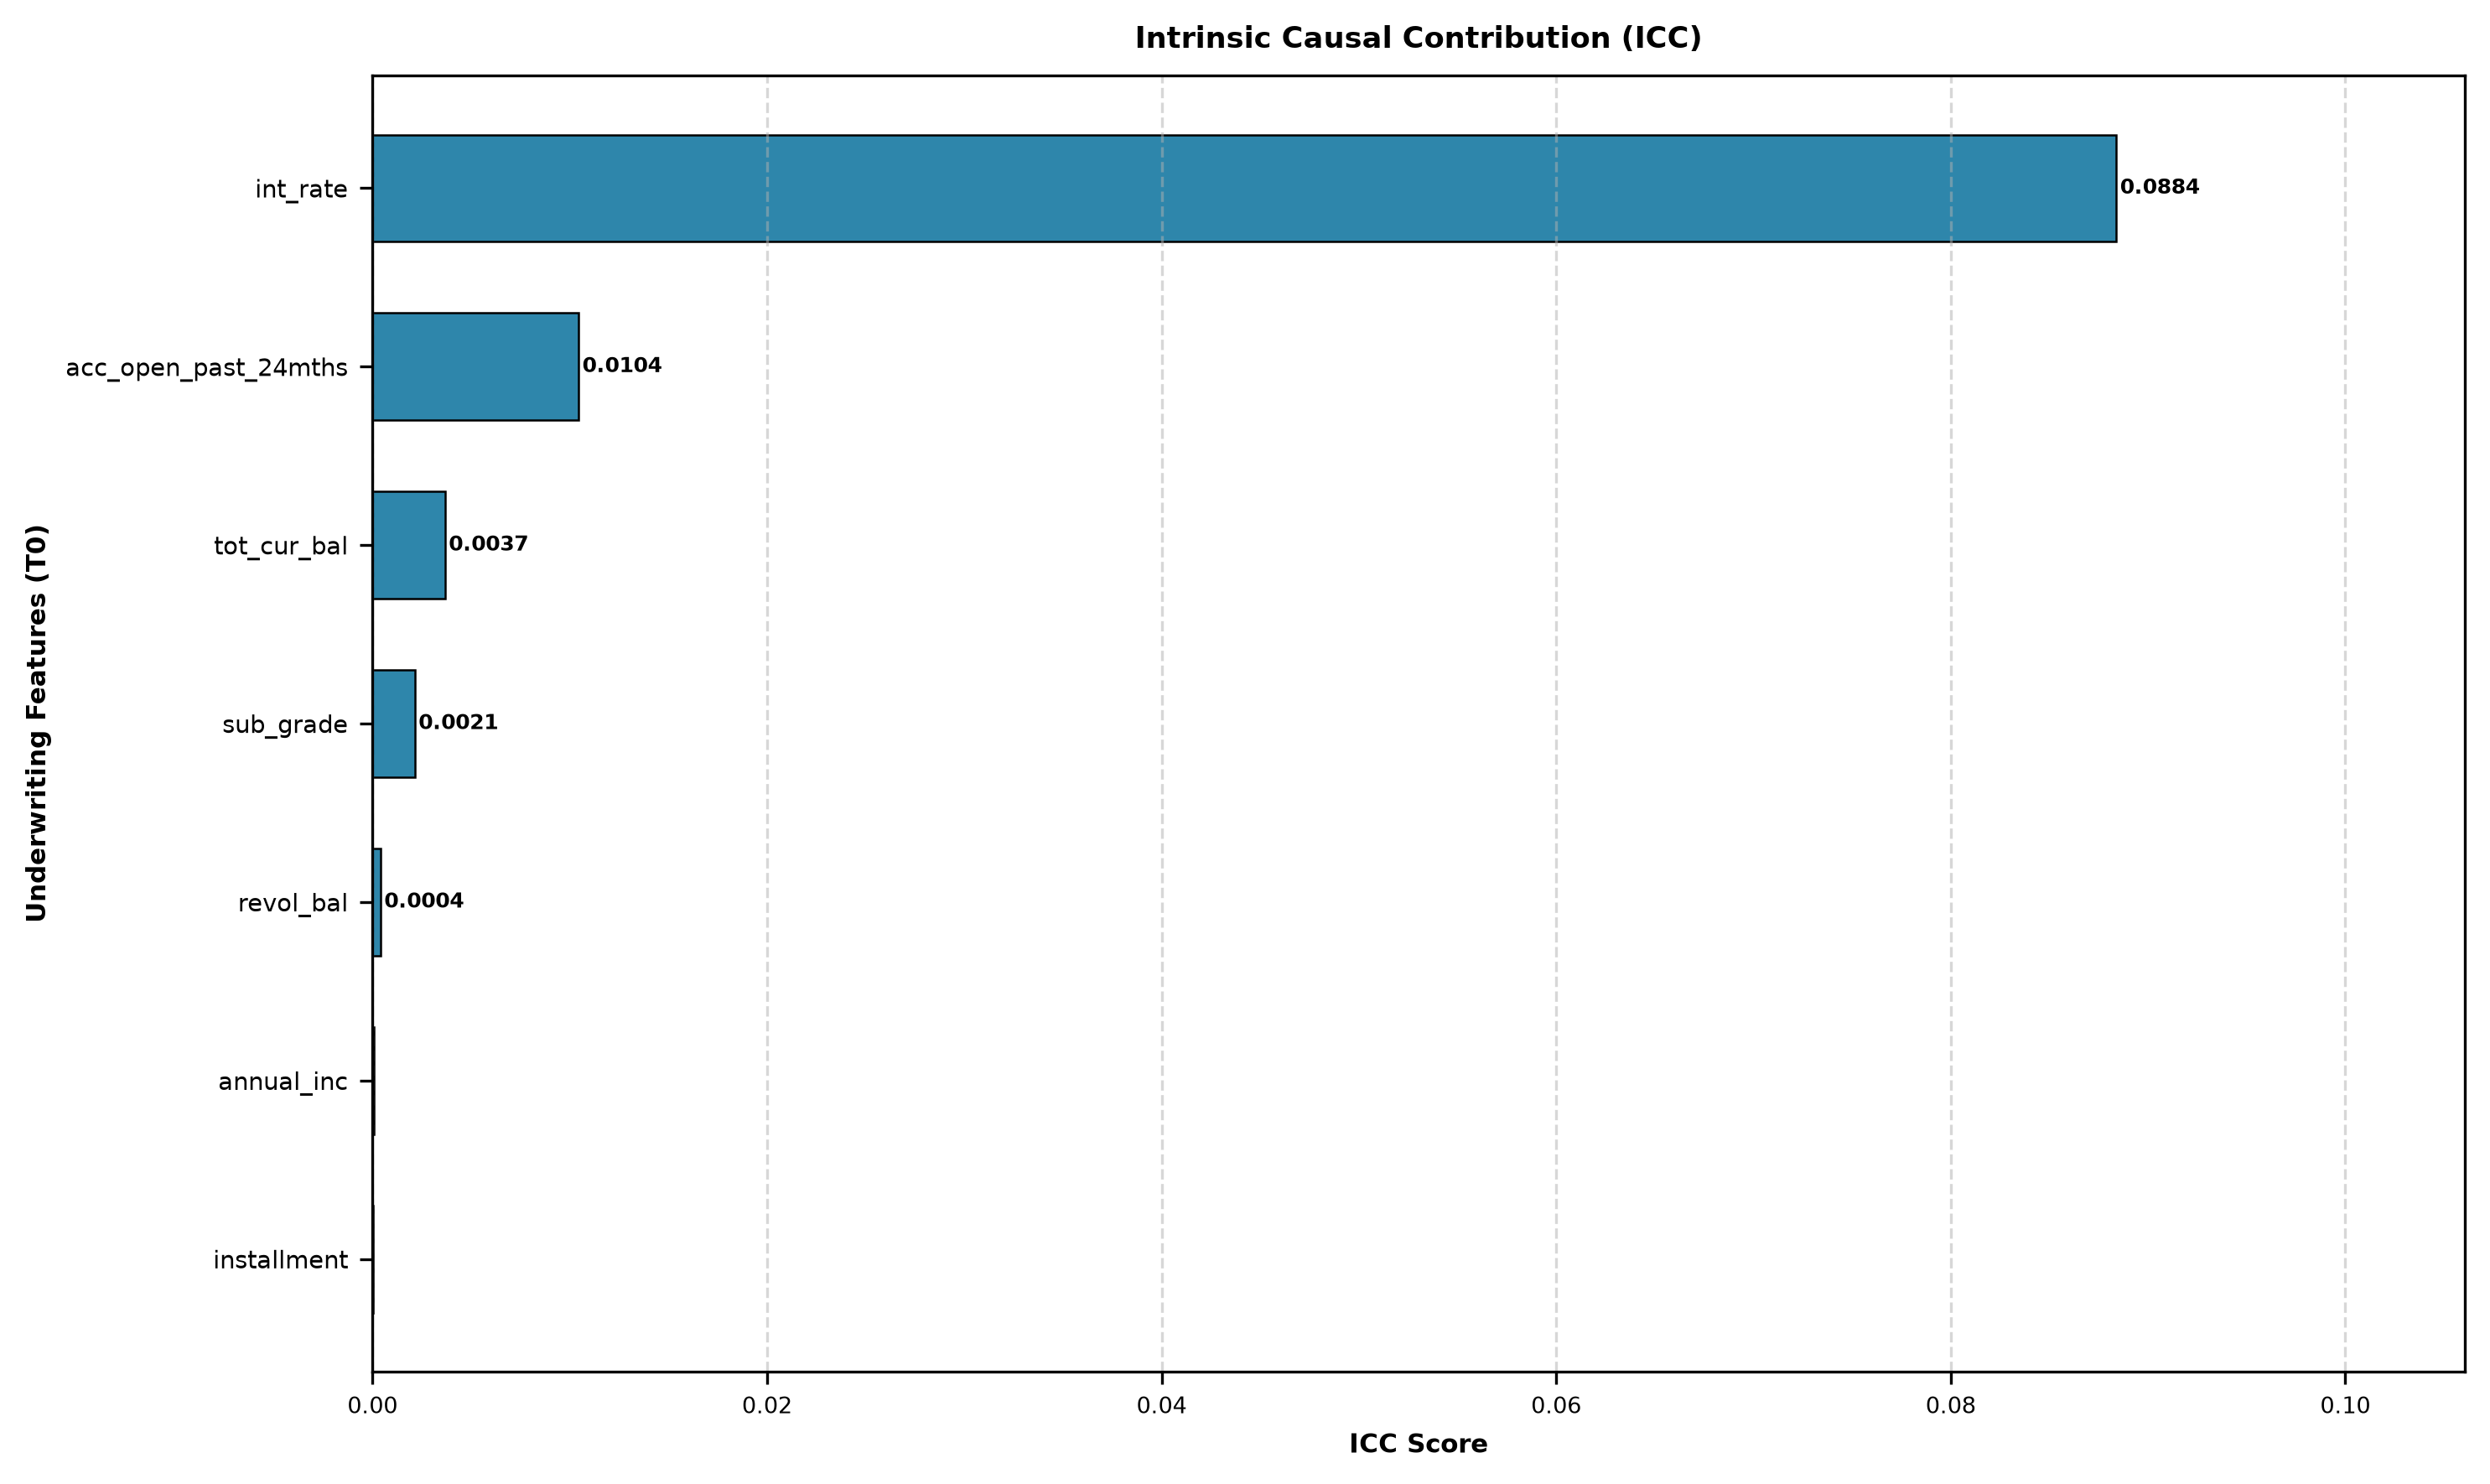


BẢNG XẾP HẠNG CĂN NGUYÊN RỦI RO (TOP ROOT CAUSES THEO ICC):
 • int_rate                 : 0.0884
 • acc_open_past_24mths     : 0.0104
 • tot_cur_bal              : 0.0037
 • sub_grade                : 0.0021
 • revol_bal                : 0.0004
 • annual_inc               : 0.0001
 • installment              : 0.0000


In [5]:
# ==============================================================================
# 4. MÔ HÌNH HÓA SCM & TÍNH ĐÓNG GÓP NỘI TẠI (ICC)
# ==============================================================================
import dowhy.gcm as gcm
import matplotlib.pyplot as plt

df_fit_gcm_sub = df_fit_gcm[list(causal_graph.nodes())].copy()
df_eval_gcm_sub = df_eval_gcm[list(causal_graph.nodes())].copy()

df_fit_gcm_sub[target] = df_fit_gcm_sub[target].astype(str)
df_eval_gcm_sub[target] = df_eval_gcm_sub[target].astype(str)

scm = gcm.StructuralCausalModel(causal_graph)
gcm.auto.assign_causal_mechanisms(scm, df_fit_gcm_sub, quality=gcm.auto.AssignmentQuality.BETTER)

print("Đang huấn luyện Structural Causal Model...")
gcm.fit(scm, df_fit_gcm_sub)

# Kiểm định LMC Falsification
eval_results = gcm.evaluate_causal_model(
    scm, df_eval_gcm_sub,
    evaluate_causal_mechanisms=False,
    compare_mechanism_baselines=False,
    evaluate_invertibility_assumptions=False,
    evaluate_causal_structure=True
)
print(eval_results)

# Tính điểm ICC
print("\nĐang tính toán Intrinsic Causal Contribution (ICC)...")
icc_scores = gcm.intrinsic_causal_influence(scm, target_node=target)
icc_series = pd.Series(icc_scores).drop(target, errors='ignore').sort_values(ascending=True)

# Vẽ biểu đồ chuẩn 1 cột bài báo
plt.figure(figsize=(10, 6), dpi=300)
bars = plt.barh(icc_series.index, icc_series.values, color='#2E86AB', edgecolor='black', height=0.6, lw=0.6)
plt.title('Intrinsic Causal Contribution (ICC)', fontsize=8.5, fontweight='bold', pad=8)
plt.xlabel('ICC Score', fontsize=7.5, fontweight='bold')
plt.ylabel('Underwriting Features (T0)', fontsize=7.5, fontweight='bold')
plt.xticks(fontsize=6.5)
plt.yticks(fontsize=7)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    w = bar.get_width()
    if w > 0.0002:
        plt.text(w + 0.0002, bar.get_y() + bar.get_height()/2, f'{w:.4f}', va='center', ha='left', fontsize=6, fontweight='bold')

plt.xlim(0, max(icc_series.values) * 1.2)
plt.tight_layout()
# plt.savefig("icc_ranking_lingam.pdf", bbox_inches='tight')
plt.show()

print("\nBẢNG XẾP HẠNG CĂN NGUYÊN RỦI RO (TOP ROOT CAUSES THEO ICC):")
for feat, sc in icc_series.sort_values(ascending=False).items():
    print(f" • {feat:25s}: {sc:.4f}")


--- HIỆU NĂNG MÔ HÌNH XÉT DUYỆT CATBOOST TẠI T0 ---
Accuracy : 0.6472
Precision: 0.6457
Recall   : 0.6525
F1-Score : 0.6491
ROC-AUC  : 0.6963


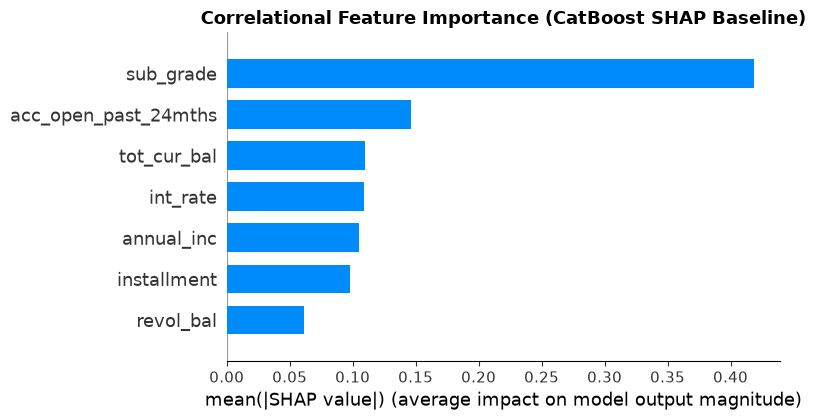

In [6]:
# ==============================================================================
# 5. MÔ HÌNH HỌC MÁY BASELINE CATBOOST VÀ SO SÁNH VỚI SHAP
# ==============================================================================
from catboost import CatBoostClassifier
import shap
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train = df_fit[causal_ancestors]
y_train = df_fit[target]
X_test = df_eval[causal_ancestors]
y_test = df_eval[target]

# Huấn luyện CatBoostClassifier
cb_model = CatBoostClassifier(iterations=250, learning_rate=0.06, depth=5, random_seed=42, verbose=0)
cb_model.fit(X_train, y_train)

y_pred = cb_model.predict(X_test)
y_prob = cb_model.predict_proba(X_test)[:, 1]

print("\n--- HIỆU NĂNG MÔ HÌNH XÉT DUYỆT CATBOOST TẠI T0 ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

# Trích xuất SHAP
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
plt.title("Correlational Feature Importance (CatBoost SHAP Baseline)", fontsize=13, fontweight='bold')
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

-> Đã xuất đồ thị động hoàn toàn: 'fig_shap_vs_icc_unified.pdf'


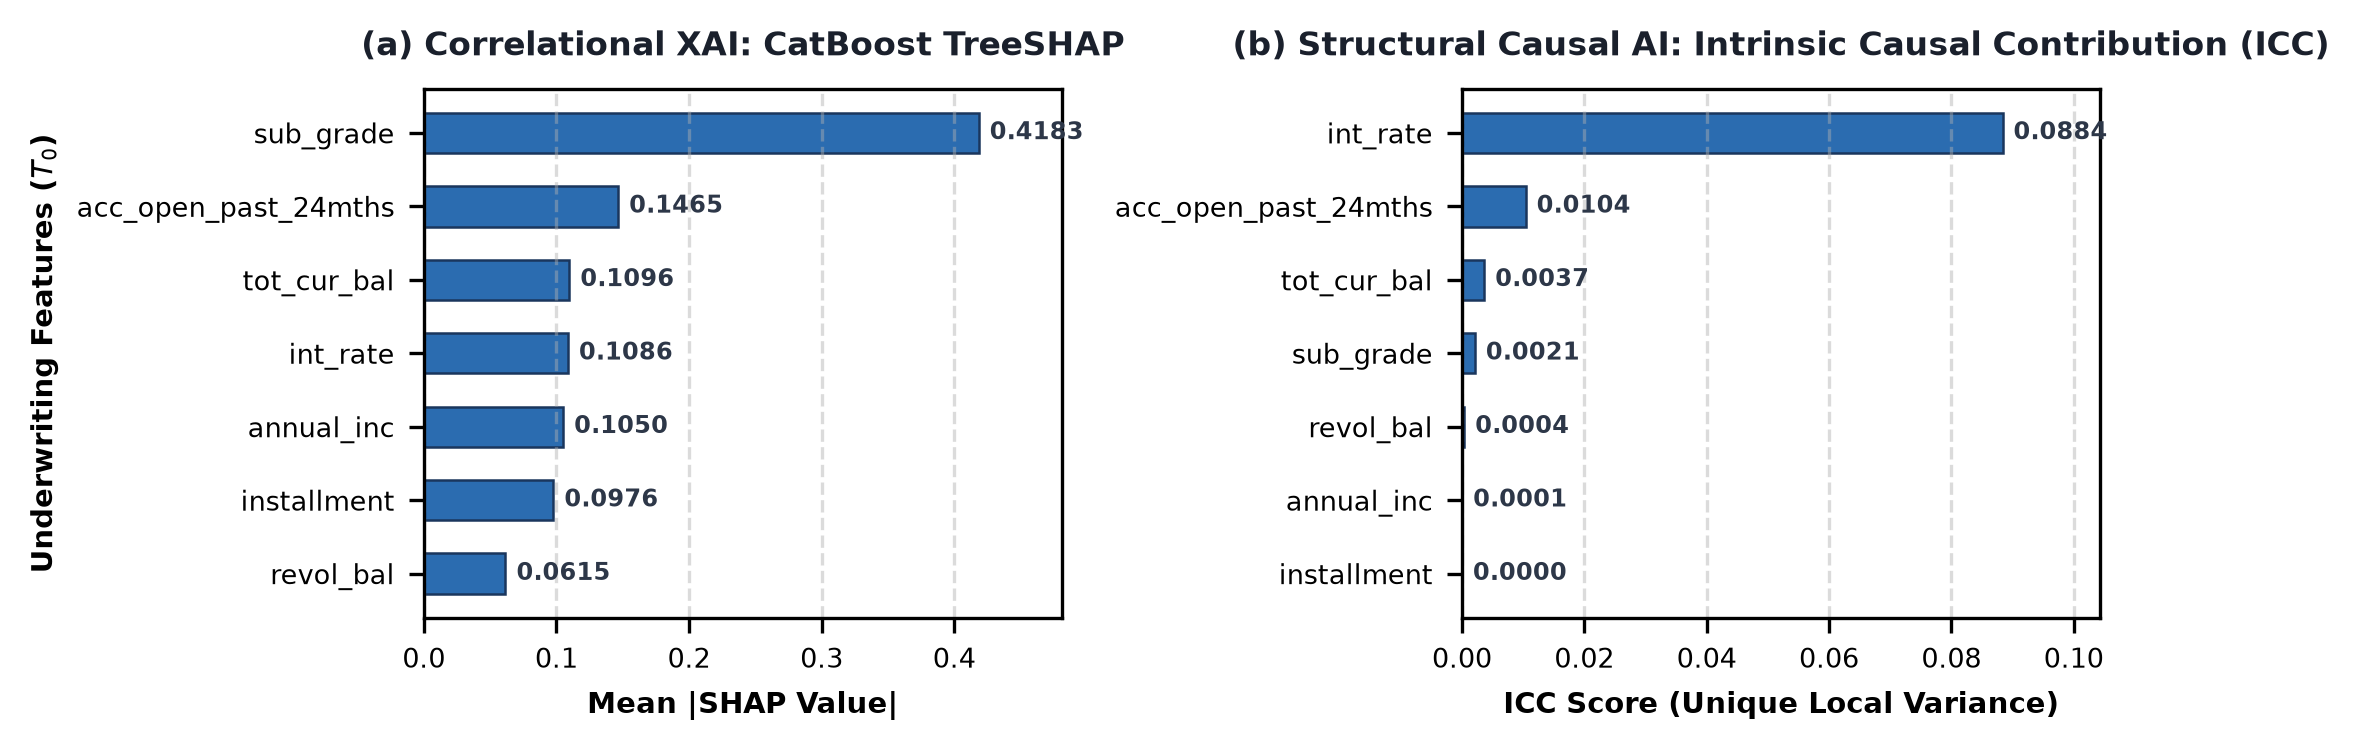

In [10]:
# ==============================================================================
# VẼ ĐỒ THỊ ĐỐI SÁNH SHAP VS ICC CHUẨN XUẤT BẢN (LẤY SỐ LIỆU ĐỘNG 100%)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. TỰ ĐỘNG TÍNH TOÁN SHAP SERIES TỪ SHAP_VALUES VÀ X_TEST (KHÔNG CẦN HARDCODE)
# ------------------------------------------------------------------------------
# Kiểm tra nếu shap_values trả về dạng list (cho 2 class) thì lấy class 1
vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# Tính trung bình trị tuyệt đối dọc theo tất cả các dòng (axis=0)
mean_abs_shap = np.abs(vals).mean(axis=0)

# Tạo Pandas Series tự động gắn với tên cột của X_test và sắp xếp tăng dần
shap_s = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=True)

# ------------------------------------------------------------------------------
# 2. TỰ ĐỘNG LẤY ICC SERIES TỪ KẾT QUẢ DOWHY-GCM
# ------------------------------------------------------------------------------
icc_s = pd.Series(icc_scores).drop(target, errors='ignore').sort_values(ascending=True)

# ------------------------------------------------------------------------------
# 3. KHỞI TẠO KHUNG HÌNH KÉP ĐỒNG NHẤT (1 HÀNG, 2 CỘT)
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 2.6), dpi=300, sharey=False)

bar_color = '#2B6CB0'   # Xanh Navy học thuật chuẩn IEEE
edge_color = '#1A365D'

# --- SUBPLOT 1: CATBOOST TREESHAP (ĐỘNG) ---
bars1 = ax1.barh(shap_s.index, shap_s.values, color=bar_color, edgecolor=edge_color, height=0.55, lw=0.6)
ax1.set_title('(a) Correlational XAI: CatBoost TreeSHAP', fontsize=8.0, fontweight='bold', pad=8, color='#1A202C')
ax1.set_xlabel('Mean |SHAP Value|', fontsize=7.0, fontweight='bold')
ax1.set_ylabel('Underwriting Features ($T_0$)', fontsize=7.0, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=6.5)
ax1.grid(axis='x', linestyle='--', alpha=0.45)
ax1.set_xlim(0, max(shap_s.values) * 1.15) # Tự động giãn trục X theo giá trị max thực tế

for bar in bars1:
    w = bar.get_width()
    ax1.text(w + (max(shap_s.values)*0.02), bar.get_y() + bar.get_height()/2, f'{w:.4f}', 
             va='center', ha='left', fontsize=5.8, fontweight='bold', color='#2D3748')

# --- SUBPLOT 2: CAUSAL ICC (ĐỘNG) ---
bars2 = ax2.barh(icc_s.index, icc_s.values, color=bar_color, edgecolor=edge_color, height=0.55, lw=0.6)
ax2.set_title('(b) Structural Causal AI: Intrinsic Causal Contribution (ICC)', fontsize=8.0, fontweight='bold', pad=8, color='#1A202C')
ax2.set_xlabel('ICC Score (Unique Local Variance)', fontsize=7.0, fontweight='bold')
ax2.tick_params(axis='both', which='major', labelsize=6.5)
ax2.grid(axis='x', linestyle='--', alpha=0.45)
ax2.set_xlim(0, max(icc_s.values) * 1.18) # Tự động giãn trục X theo giá trị max thực tế

for bar in bars2:
    w = bar.get_width()
    ax2.text(w + (max(icc_s.values)*0.02), bar.get_y() + bar.get_height()/2, f'{w:.4f}', 
             va='center', ha='left', fontsize=5.8, fontweight='bold', color='#2D3748')

plt.tight_layout()

# Xuất ra file vector PDF duy nhất
plt.savefig("fig_shap_vs_icc_unified.pdf", bbox_inches='tight')
plt.savefig("fig_shap_vs_icc_unified.png", dpi=300, bbox_inches='tight')
print("-> Đã xuất đồ thị động hoàn toàn: 'fig_shap_vs_icc_unified.pdf'")
plt.show()

In [8]:
# ==============================================================================
# 6. THỰC NGHIỆM ĐỀ XUẤT HÀNH ĐỘNG PHẢN THỰC TẾ (ACTIONABLE RECOURSE)
# ==============================================================================
available_nodes = [n for n in causal_graph.nodes() if n != target]
print("Các biến hiện diện trong mô hình SCM của DirectLiNGAM:", available_nodes)

# Xác định danh sách các đòn bẩy can thiệp thực tế có trong đồ thị
potential_levers = ['installment', 'loan_amnt', 'int_rate', 'revol_util', 'dti']
active_levers = [col for col in potential_levers if col in available_nodes]
print(f"-> Các đòn bẩy chính sách khả dụng để can thiệp: {active_levers}")

# Hàm đánh giá can thiệp đa biến qua SCM (do-calculus)
def simulate_policy_recourse(applicant_data, interventions_dict):
    custom_interventions = {}
    for col in available_nodes:
        val = applicant_data[col].values[0]
        try:
            val_clean = float(str(val).replace('%', '').strip())
            if '%' in str(val):
                val_clean /= 100.0
        except:
            val_clean = val
        custom_interventions[col] = lambda x, v=val_clean: v
        
    for node, new_val in interventions_dict.items():
        custom_interventions[node] = lambda x, v=new_val: v
        
    samples = gcm.interventional_samples(scm, custom_interventions, num_samples_to_draw=1000)
    return (samples[target].values == '1').mean()

# Hàm tự động tạo gói can thiệp tái cấu trúc dựa trên các đòn bẩy sẵn có
def build_restructure_plan(applicant_row, intensity=0.30):
    plan = {}
    for lever in active_levers:
        orig_v = float(applicant_row[lever].values[0])
        # Giảm lãi suất, giảm số tiền vay, hoặc giảm tỷ lệ nợ
        plan[lever] = orig_v * (1.0 - intensity)
    return plan

# ------------------------------------------------------------------------------
# TRƯỜNG HỢP 1: TÌM ỨNG VIÊN CẬN BIÊN CÓ THỂ CỨU VÃN (REJECT -> APPROVE)
# ------------------------------------------------------------------------------
found_case = False
borderline_indices = np.where((y_prob >= 0.51) & (y_prob <= 0.68))[0]

for idx in borderline_indices:
    sample_app = df_eval_gcm_sub.iloc[[idx]].copy()
    base_p = y_prob[idx]
    
    # Tạo gói can thiệp vừa phải (giảm 25% gánh nặng tài chính từ các đòn bẩy)
    interv_plan = build_restructure_plan(sample_app, intensity=0.25)
    
    if len(interv_plan) > 0:
        sim_p = simulate_policy_recourse(sample_app, interv_plan)
        if sim_p < 0.50:
            cand_idx = idx
            cand_applicant = sample_app
            cand_prob = base_p
            rescued_prob = sim_p
            active_plan = interv_plan
            found_case = True
            break

# Nếu quét nhóm 51-68% chưa có, lấy hồ sơ cận biên đầu tiên để can thiệp sâu hơn
if not found_case and len(borderline_indices) > 0:
    cand_idx = borderline_indices[0]
    cand_applicant = df_eval_gcm_sub.iloc[[cand_idx]].copy()
    cand_prob = y_prob[cand_idx]
    active_plan = build_restructure_plan(cand_applicant, intensity=0.35)
    rescued_prob = simulate_policy_recourse(cand_applicant, active_plan)

print("\n" + "="*75)
print(f"TRƯỜNG HỢP 1: ỨNG VIÊN CẬN BIÊN (MÃ HỒ SƠ: #{cand_idx})")
print(f" -> Quyết định ban đầu: TỪ CHỐI (Xác suất rủi ro dự báo: {cand_prob*100:.2f}%)")
print("="*75)
print(f"[Chính sách Tái cấu trúc nợ áp dụng trên các đòn bẩy: {list(active_plan.keys())}]:")
for k, v in active_plan.items():
    orig_k = float(cand_applicant[k].values[0])
    print(f"   • {k:15s}: {orig_k:.4f} -> Can thiệp giảm còn: {v:.4f}")
print(f" -> Rủi ro vỡ nợ ban đầu: {cand_prob*100:.2f}% | Rủi ro sau can thiệp: {rescued_prob*100:.2f}%")

print("\n--- KẾT LUẬN XÉT DUYỆT THÔNG MINH ---")
if rescued_prob < 0.50:
    print(f"✅ CHẤP THUẬN PHÊ DUYỆT CÓ ĐIỀU KIỆN (CONDITIONAL APPROVAL)!")
    print(f"   Khoản vay chuyển từ [TỪ CHỐI] thành [ĐỦ CHUẨN AN TOÀN] (Rủi ro còn {rescued_prob*100:.2f}%).")
else:
    print(f"   Rủi ro đã giảm đáng kể (còn {rescued_prob*100:.2f}%), khuyến nghị bổ sung tài sản bảo đảm.")

# ------------------------------------------------------------------------------
# TRƯỜNG HỢP 2: ỨNG VIÊN SIÊU RỦI RO (TỪ CHỐI DỨT KHOÁT)
# ------------------------------------------------------------------------------
extreme_idx = np.argmax(y_prob)
ext_app = df_eval_gcm_sub.iloc[[extreme_idx]].copy()
ext_p = y_prob[extreme_idx]

print("\n" + "="*75)
print(f"TRƯỜNG HỢP 2: ỨNG VIÊN SIÊU RỦI RO (MÃ HỒ SƠ: #{extreme_idx})")
print(f" -> Xác suất vỡ nợ gốc: {ext_p*100:.2f}%")
print("="*75)

# Áp dụng can thiệp tối đa (-40% trên toàn bộ các đòn bẩy)
extreme_plan = build_restructure_plan(ext_app, intensity=0.40)
ext_res_p = simulate_policy_recourse(ext_app, extreme_plan)

print(f"Áp dụng can thiệp chính sách tối đa (-40% trên {list(extreme_plan.keys())}):")
print(f" -> Rủi ro sau can thiệp tối đa: {ext_res_p*100:.2f}%")
if ext_res_p >= 0.50:
    print("❌ KẾT LUẬN: TỪ CHỐI DỨT KHOÁT. Hồ sơ mang rủi ro cấu trúc quá lớn, không thể cứu vãn.")
print("="*75)

Các biến hiện diện trong mô hình SCM của DirectLiNGAM: ['revol_bal', 'int_rate', 'sub_grade', 'annual_inc', 'installment', 'acc_open_past_24mths', 'tot_cur_bal']
-> Các đòn bẩy chính sách khả dụng để can thiệp: ['installment', 'int_rate']

TRƯỜNG HỢP 1: ỨNG VIÊN CẬN BIÊN (MÃ HỒ SƠ: #11)
 -> Quyết định ban đầu: TỪ CHỐI (Xác suất rủi ro dự báo: 51.68%)
[Chính sách Tái cấu trúc nợ áp dụng trên các đòn bẩy: ['installment', 'int_rate']]:
   • installment    : 0.1939 -> Can thiệp giảm còn: 0.1454
   • int_rate       : 0.3575 -> Can thiệp giảm còn: 0.2681
 -> Rủi ro vỡ nợ ban đầu: 51.68% | Rủi ro sau can thiệp: 48.20%

--- KẾT LUẬN XÉT DUYỆT THÔNG MINH ---
✅ CHẤP THUẬN PHÊ DUYỆT CÓ ĐIỀU KIỆN (CONDITIONAL APPROVAL)!
   Khoản vay chuyển từ [TỪ CHỐI] thành [ĐỦ CHUẨN AN TOÀN] (Rủi ro còn 48.20%).

TRƯỜNG HỢP 2: ỨNG VIÊN SIÊU RỦI RO (MÃ HỒ SƠ: #1427)
 -> Xác suất vỡ nợ gốc: 93.63%
Áp dụng can thiệp chính sách tối đa (-40% trên ['installment', 'int_rate']):
 -> Rủi ro sau can thiệp tối đa: 82.00%
❌